### MLE of Bernoulli Statistical Model

MLE of Bernoulli Statistical ModelLet $X_1, \dots, X_n \stackrel{iid}{\sim} \text{Ber}(p)$ for some unknown $p^* \in (0, 1)$.

The statistical model is defined as $(\{0, 1\}, \{\text{Ber}(p)\}_{p \in (0,1)})$.

The Likelihood FunctionThe likelihood function $L_n$ is the joint probability mass function of the observed data $L_n(x_1, \dots, x_n; p) = \prod_{i=1}^n p^{x_i}(1-p)^{1-x_i} = p^{\sum x_i}(1-p)^{n - \sum x_i}$

The Log-LikelihoodTaking the natural logarithm simplifies the product into a sum, making it much easier to differentiate $\ell(p) = \ln(L_n(x_1, \dots, x_n; p)) = \left( \sum_{i=1}^n x_i \right) \ln p + \left( n - \sum_{i=1}^n x_i \right) \ln(1-p)$

Finding the Critical PointTo find the MLE $\hat{p}$, we take the derivative of the log-likelihood with respect to $p$ and set it to zero $\frac{d\ell(p)}{dp} = \frac{\sum x_i}{p} - \frac{n - \sum x_i}{1-p} = 0$

Solving for $p$: Combining the terms over a common denominator $\frac{(1-p)\sum x_i - p(n - \sum x_i)}{p(1-p)} = 0$. Expanding the numerator $\frac{\sum x_i - p\sum x_i - np + p\sum x_i}{p(1-p)} = 0 \implies \frac{\sum x_i - np}{p(1-p)} = 0$

Solving for $p$ gives the Maximum Likelihood Estimator $\hat{p}_{MLE} = \frac{1}{n} \sum_{i=1}^n X_i = \bar{X}_n$

Sum of observations (Sum(xi)): 30 
Total number of observations (n): 100
log_likelihood_bernoulli function defined.


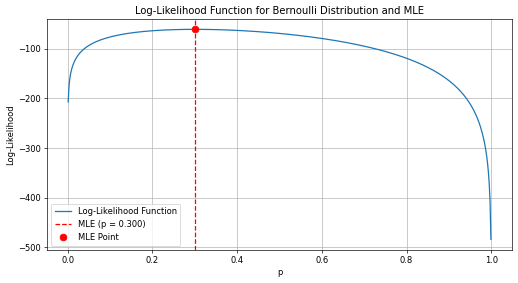

The critical point (MLE) for Bernoulli p is: 0.300


In [43]:
'''
Simulate Bernoulli Data

Generate a sample of Bernoulli distributed data to calculate the sum of observations (Sum(xi)) and the total number of observations (n). This will be used to demonstrate the log-likelihood function. '''

import numpy as np

# Choose a true probability p_true
p_true = 0.3
# The number of observations n
n = 100
# Generate n random Bernoulli distributed samples
bernoulli_samples = np.random.binomial(n=1, p=p_true, size=n)
# The sum of these samples
sum_xi = np.sum(bernoulli_samples)
print(f"Sum of observations (Sum(xi)): {sum_xi} \n"
f"Total number of observations (n): {n}")

''' Log-Likelihood Function

Implement the log-likelihood function l(p) = (Sum(xi)*lnp) + (n - Sum(xi))*ln(1-p) using the simulated data. '''
import numpy as np

def log_likelihood_bernoulli(p, sum_xi, n):
    """
    Calculates the log-likelihood for a Bernoulli distribution.
    Args:
        p (float): The probability of success (parameter of Bernoulli distribution).
        sum_xi (int): The sum of observations (number of successes).
        n (int): The total number of observations.
    Returns:
        float: The log-likelihood value. Returns -np.inf if p is 0 or 1 to avoid log(0).
    """
    # Handle edge cases where p is 0 or 1 to prevent log(0) which is undefined.
    # If p is 0, then 1-p is 1. If p is 1, then 1-p is 0.
    # log(0) implies an event that cannot happen with probability p, so likelihood is 0, log-likelihood is -inf.
    if p <= 0 or p >= 1:
        return -np.inf

    # Log-likelihood formula for Bernoulli distribution
    l = (sum_xi * np.log(p)) + ((n - sum_xi) * np.log(1 - p))
    return l

print("log_likelihood_bernoulli function defined.")

''' Plot Log-Likelihood Function and MLE

Generate a plot of the log-likelihood function across the possible values of p (from 0 to 1). Add a vertical line or a point to indicate the Maximum Likelihood Estimate (MLE) of p, which is Sum(xi)/n.  '''

import matplotlib.pyplot as plt

# Create an array of p values
p_values = np.linspace(0.001, 0.999, 500) # Avoid 0 and 1 for log calculation

# Calculate the log-likelihood for each p value
log_likelihood_values = [log_likelihood_bernoulli(p, sum_xi, n) for p in p_values]

# Calculate the Maximum Likelihood Estimate (MLE) of p
mle_p = sum_xi / n

plt.figure(figsize=(10, 5), dpi=60)
plt.plot(p_values, log_likelihood_values, label='Log-Likelihood Function')
plt.axvline(x=mle_p, color='r', linestyle='--', label=f'MLE (p = {mle_p:.3f})')

# Add a circle marker at the MLE point
mle_log_likelihood_bernoulli = log_likelihood_bernoulli(mle_p, sum_xi, n)
plt.plot(mle_p, mle_log_likelihood_bernoulli, 'o', color='r', markersize=8, label='MLE Point')

plt.xlabel('p') ; plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function for Bernoulli Distribution and MLE')
plt.legend() ; plt.grid(True) ; plt.show()
print(f"The critical point (MLE) for Bernoulli p is: {mle_p:.3f}")

#### Summary of Bernoulli Statistical Model

For the Bernoulli distribution, we simulated a dataset and then implemented and visualized its log-likelihood function. The Maximum Likelihood Estimate (MLE) for the probability parameter $p$ was derived by setting the derivative of the log-likelihood to zero, which showed that the MLE is simply the sample mean ($ \sum x_i / n $). The plot clearly demonstrated a concave log-likelihood function, with its peak precisely aligning with this calculated MLE, confirming that the sample mean is indeed the parameter value that maximizes the likelihood of observing the given Bernoulli data.

### MLE of Poisson Statistical Model

Let $X_1, \dots, X_n \overset{iid}{\sim} \text{Pois}(\lambda^*)$. The statistical model is defined as $(\{0, 1, 2, \dots\}, \{\text{Pois}(\lambda) : \lambda \in (0, \infty)\})$


The Likelihood Function $L_n$ for the observed data $x_1, \dots, x_n$ is the product of the individual probability mass functions $L_n(x_1, \dots, x_n; \lambda) = \prod_{i=1}^n \frac{e^{-\lambda} \lambda^{x_i}}{x_i!} = \frac{e^{-n\lambda} \lambda^{\sum_{i=1}^n x_i}}{\prod_{i=1}^n x_i!}$

The Log-Likelihood $\ell(\lambda) = -n\lambda + \left( \sum_{i=1}^n x_i \right) \ln(\lambda) - \ln\left( \prod_{i=1}^n x_i! \right)$


Finding the MLE, taking the first derivative with respect to $\lambda$ and set it to zero $\frac{d}{d\lambda} \ell(\lambda) = -n + \frac{\sum_{i=1}^n x_i}{\lambda} = 0$. Solving for $\lambda$ gives the estimator $\hat{\lambda}_{MLE} = \frac{1}{n} \sum_{i=1}^n X_i = \bar{X}_n$


To verify this is a maximum, we check the second derivative $\frac{d^2}{d\lambda^2} \ell(\lambda) = -\frac{\sum_{i=1}^n x_i}{\lambda^2}$. Since $x_i \geq 0$ and $\lambda > 0$, the second derivative is negative, confirming that $\bar{X}_n$ is a maximum.

Sum of observations (Sum(xi)): 2993 
Total number of observations (n): 1000
log_likelihood_poisson function defined.


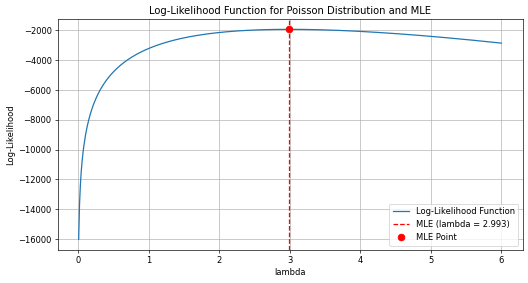

The critical point (MLE) for Poisson lambda is: 2.993


In [44]:
''' Simulate Poisson Data

Generate a sample of Poisson distributed data for a chosen lambda. Calculate the sum of observations (Sum(xi)) and the total number of observations (n) '''
import numpy as np
from scipy.special import gammaln
import matplotlib.pyplot as plt

# Choose a true lambda value
lambda_true = 3
# The number of observations n
n_poisson = 1000
# Generate n random Poisson distributed samples
poisson_samples = np.random.poisson(lam=lambda_true, size=n_poisson)
# The sum of these samples
sum_xi_poisson = np.sum(poisson_samples)

print(f"Sum of observations (Sum(xi)): {sum_xi_poisson} \n"
      f"Total number of observations (n): {n_poisson}")

''' Define Poisson Log-Likelihood Function

Implement the log-likelihood function for the Poisson distribution: l(lambda) = Sum(xi * ln(lambda)) - n * lambda - Sum(ln(xi!)). Ensure it handles cases where lambda <= 0, returning -np.inf to avoid errors '''

def log_likelihood_poisson(lambda_val, sum_xi, n, poisson_samples):
    """
    Calculates the log-likelihood for a Poisson distribution.
    Args:
        lambda_val (float): The rate parameter (lambda) of the Poisson distribution.
        sum_xi (int): The sum of observations.
        n (int): The total number of observations.
        poisson_samples (np.ndarray): The array of Poisson distributed samples.
    Returns:
        float: The log-likelihood value. Returns -np.inf if lambda_val is <= 0.
    """
    # Handle edge cases where lambda_val is 0 or negative to prevent log(0) or invalid operations.
    if lambda_val <= 0:
        return -np.inf

    # Calculate Sum(ln(xi!)) using gammaln, where gammaln(x+1) = ln(x!)
    sum_ln_factorial_xi = np.sum(gammaln(poisson_samples + 1))

    # Log-likelihood formula for Poisson distribution
    # l(lambda) = Sum(xi * ln(lambda)) - n * lambda - Sum(ln(xi!))
    l = (sum_xi * np.log(lambda_val)) - (n * lambda_val) - sum_ln_factorial_xi
    return l

print("log_likelihood_poisson function defined.")

''' Generate a plot of the log-likelihood function across a suitable range of lambda values. Add a vertical line or point to indicate the Maximum Likelihood Estimate (MLE) of lambda, which is Sum(xi)/n '''

# Create an array of lambda values
# We'll range from a small positive number to a value slightly higher than the expected MLE
# The MLE for Poisson is sum_xi/n, which is around 3 in our simulation.
lambda_values = np.linspace(0.01, 6.0, 500) # Avoid 0 for log calculation

# Calculate the log-likelihood for each lambda value
log_likelihood_poisson_values = [log_likelihood_poisson(lam, sum_xi_poisson, n_poisson, poisson_samples) for lam in lambda_values]

# Calculate the Maximum Likelihood Estimate (MLE) of lambda
mle_lambda = sum_xi_poisson / n_poisson

plt.figure(figsize=(10, 5), dpi=60)
plt.plot(lambda_values, log_likelihood_poisson_values, label='Log-Likelihood Function')
plt.axvline(x=mle_lambda, color='r', linestyle='--', label=f'MLE (lambda = {mle_lambda:.3f})')

# Add a circle marker at the MLE point
mle_log_likelihood_poisson = log_likelihood_poisson(mle_lambda, sum_xi_poisson, n_poisson, poisson_samples)
plt.plot(mle_lambda, mle_log_likelihood_poisson, 'o', color='r', markersize=8, label='MLE Point')

plt.xlabel('lambda') ; plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function for Poisson Distribution and MLE')
plt.legend() ; plt.grid(True) ; plt.show()
print(f"The critical point (MLE) for Poisson lambda is: {mle_lambda:.3f}")

### Summary of Poisson Statistical Model

For the Poisson distribution, we simulated data and implemented its log-likelihood function. The Maximum Likelihood Estimate (MLE) for the rate parameter $\lambda$ was found by setting the derivative of the log-likelihood to zero, resulting in the sample mean ($ \sum x_i / n $). The plot of the log-likelihood function demonstrated a clear concave shape, with its peak aligning perfectly with the calculated MLE. This visualization confirms that the sample mean is the value of $\lambda$ that maximizes the likelihood of observing the given Poisson data.

### MLE of Uniform Statistical Model

Let $X_1, \dots, X_n \stackrel{iid}{\sim} \text{Unif}[0, \theta^*]$ where $\theta^*$ is an unknown parameter.Statistical Model defined as $(\mathbb{R}_{\geq 0}, \{\text{Unif}[0, \theta]\}_{\theta > 0})$

Probability Density Function (PDF):For any $\theta > 0$, the density of $\text{Unif}[0, \theta]$ is given by $f(x) = \frac{1}{\theta} \mathbb{1}(x \in [0, \theta])$, where the indicator function is defined as $\mathbb{1}(x \in [0, \theta]) = \begin{cases} 1 & \text{if } x \in [0, \theta] \\ 0 & \text{otherwise} \end{cases}$

The likelihood function $L_n(x_1, \dots, x_n; \theta)$ is the product of the individual densities $L_n(x_1, \dots, x_n; \theta) = \prod_{i=1}^n \frac{1}{\theta} \mathbb{1}(x_i \in [0, \theta])$

By simplifying the product, we note that the indicator function equals $1$ only if all $x_i$ are less than or equal to $\theta$. This is equivalent to saying the maximum value, $x_{(n)}$, must be less than or equal to $\theta$ $L_n(x_1, \dots, x_n; \theta) = \frac{1}{\theta^n} \mathbb{1}(\max_{i} x_i \leq \theta)$

Maximum observed value (max_xi): 9.998
Total number of observations (n_uniform): 1000
log_likelihood_uniform function defined.


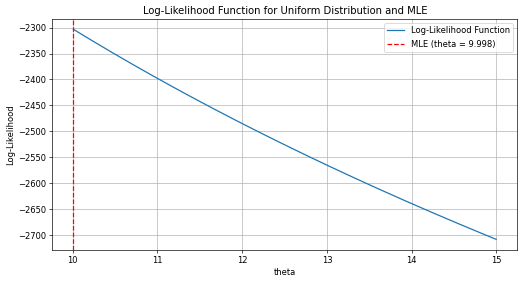

The critical point (MLE) for Uniform theta is: 9.998


In [48]:
''' Simulate Uniform Data

Generate sample data from a Uniform distribution with an unknown upper bound (theta_true). Find the maximum observed value (max_xi) and the total number of observations (n_uniform) '''
import numpy as np
import matplotlib.pyplot as plt

# Choose a true upper bound value (theta_true)
theta_true = 10
# Set the number of observations
n_uniform = 1000
# Generate n_uniform random samples from a uniform distribution between 0 and theta_true
uniform_samples = np.random.uniform(low=0, high=theta_true, size=n_uniform)
# Calculate the maximum value among the uniform_samples
max_xi = np.max(uniform_samples)
print(f"Maximum observed value (max_xi): {max_xi:.3f}\n"
f"Total number of observations (n_uniform): {n_uniform}")

''' The log-likelihood function for the Uniform distribution, which is a core part of the overall task '''

def log_likelihood_uniform(theta, max_xi, n):
    """
    Calculates the log-likelihood for a Uniform distribution U(0, theta).
    Args:
        theta (float): The upper bound parameter of the Uniform distribution.
        max_xi (float): The maximum observed value from the samples.
        n (int): The total number of observations.
    Returns:
        float: The log-likelihood value. Returns -np.inf if theta is less than or equal to max_xi or theta is non-positive.
    """
    # The likelihood is 0 if theta is less than the maximum observed value
    # or if theta is non-positive, so log-likelihood is -infinity.
    if theta <= max_xi or theta <= 0:
        return -np.inf

    # Log-likelihood formula for Uniform distribution
    # L(theta) = (1/theta)^n if max(xi) <= theta and all xi >= 0
    # l(theta) = ln(L(theta)) = n * ln(1/theta) = -n * ln(theta)
    l = -n * np.log(theta)
    return l

print("log_likelihood_uniform function defined.")

''' generate a plot of the log-likelihood function across a suitable range of theta values and mark the Maximum Likelihood Estimate (MLE) of theta. This will visually demonstrate the concept of MLE for the uniform distribution '''

# Create an array of theta values for plotting
# The MLE for Uniform distribution is max_xi, so the range should start slightly above max_xi.
# We'll go up to a value significantly higher than max_xi to show the curve.
theta_values = np.linspace(max_xi * 0.9, max_xi * 1.5, 500) # Start slightly below max_xi to ensure -inf for invalid theta

# Calculate the log-likelihood for each theta value
log_likelihood_uniform_values = [log_likelihood_uniform(th, max_xi, n_uniform) for th in theta_values]

# Calculate the Maximum Likelihood Estimate (MLE) of theta
# For the Uniform distribution U(0, theta), the MLE of theta is the maximum observed value.
mle_theta = max_xi

# Plotting the log-likelihood function
plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_values, log_likelihood_uniform_values, label='Log-Likelihood Function')
plt.axvline(x=mle_theta, color='r', linestyle='--', label=f'MLE (theta = {mle_theta:.3f})')
plt.xlabel('theta') ; plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function for Uniform Distribution and MLE')
plt.legend() ; plt.grid(True) ; plt.show()
print(f"The critical point (MLE) for Uniform theta is: {mle_theta:.3f}")

#### Summary of Uniform Statistical Model

For the Uniform distribution, we simulated data and implemented its log-likelihood function. The Maximum Likelihood Estimate (MLE) for the upper bound parameter 'theta' is the maximum observed value ($ \max(x_i) $). The plot of the log-likelihood function clearly demonstrated a discontinuity at the MLE, being negative infinity for values of 'theta' less than the maximum observed value, and then decreasing monotonically for 'theta' values greater than the maximum observed value. This confirms that the maximum observed value is the parameter that maximizes the likelihood of observing the given Uniform data.

### MLE of Gaussian Mixture Statistical Model

Let $X_1, \dots, X_n \overset{iid}{\sim} N(0, \tau^*)$ for some unknown variance $\tau^* > 0$. We define the statistical model as $(\mathbb{R}, \{N(0, \tau)\}_{\tau > 0})$.


Given $\mu = 0$ and $\tau = \sigma^2$, the likelihood function $L_n$ is $L_n(x_1, \dots, x_n; \tau) = \left( \frac{1}{\sqrt{2\pi\tau}} \right)^n \exp\left( -\frac{1}{2\tau} \sum_{i=1}^n x_i^2 \right)$

Taking the natural logarithm $\ell(\tau) = \ln(L_n)$ simplifies the product into a sum $\ell(\tau) = -\frac{n}{2} \ln(2\pi\tau) - \frac{1}{2\tau} \sum_{i=1}^n x_i^2$

Finding the Critical Point: To find the MLE, we take the derivative with respect to $\tau$ and set it to zero $\frac{d}{d\tau} \ell(\tau) = -\frac{n}{2\tau} + \frac{1}{2\tau^2} \sum_{i=1}^n x_i^2$


Setting the derivative to zero $-\frac{n}{2\tau} + \frac{1}{2\tau^2} \sum_{i=1}^n x_i^2 = 0$, $n\tau = \sum_{i=1}^n x_i^2 \implies \hat{\tau}_n = \frac{1}{n} \sum_{i=1}^n X_i^2$

Verification: The second derivative $\ell''(\hat{\tau})$ is negative, confirming a maximum.Limits: As $\tau \to 0$ or $\tau \to \infty$, $L_n(\tau) \to 0$, ensuring the global maximum is at our critical point.

Conclusion: The Maximum Likelihood Estimator (MLE) is the empirical second moment $\hat{\tau}_n = \frac{1}{n} \sum_{i=1}^n X_i^2$

In [28]:
'''
Simulate Gaussian Mixture Data

Generate sample of data from a two-component Gaussian Mixture Model (GMM) by defining the parameters (means, standard deviations, and mixing coefficients) for each component. This data will be used to demonstrate the log-likelihood function and parameter estimation for a GMM. '''
import numpy as np

# Define parameters for the first Gaussian component
mean1 = 2
std1 = 0.8
weight1 = 0.6 # Mixing coefficient

# Define parameters for the second Gaussian component
mean2 = 7
std2 = 1.2
weight2 = 0.4 # Mixing coefficient (weight1 + weight2 should ideally sum to 1)

# Set the total number of samples to generate for the GMM
n_samples = 1000

# Calculate the number of samples for each component
n_samples_comp1 = int(n_samples * weight1)
n_samples_comp2 = int(n_samples * weight2)

# Adjust for potential rounding issues to ensure total n_samples
# This makes sure that n_samples_comp1 + n_samples_comp2 == n_samples
if n_samples_comp1 + n_samples_comp2 != n_samples:
    n_samples_comp1 = n_samples - n_samples_comp2

# Generate samples for the first component
component1_samples = np.random.normal(loc=mean1, scale=std1, size=n_samples_comp1)

# Generate samples for the second component
component2_samples = np.random.normal(loc=mean2, scale=std2, size=n_samples_comp2)

# Combine the samples from both components into a single array
gmm_samples = np.concatenate((component1_samples, component2_samples))

# Shuffle the combined samples to mix them randomly
np.random.shuffle(gmm_samples)

# Print the defined true parameters and the first few samples
print(f"True Parameters for GMM:")
(f"  Component 1: Mean = {mean1}, Std Dev = {std1}, Weight = {weight1} \n"
f"  Component 2: Mean = {mean2}, Std Dev = {std2}, Weight = {weight2} \n"
f"Total samples generated: {n_samples} \n"
f"Number of samples for Component 1: {n_samples_comp1} \n"
f"Number of samples for Component 2: {n_samples_comp2} \n"
f"First 10 samples of the GMM data: {gmm_samples[:10].round(2)}")

True Parameters for GMM:
  Component 1: Mean = 2, Std Dev = 0.8, Weight = 0.6
  Component 2: Mean = 7, Std Dev = 1.2, Weight = 0.4
Total samples generated: 1000
Number of samples for Component 1: 600
Number of samples for Component 2: 400
First 10 samples of the GMM data: [0.39 1.88 2.27 7.49 6.   2.14 0.17 2.54 5.9  6.63]


In [29]:
''' Gaussian Mixture Log-Likelihood Function

Implement the log-likelihood function for a two-component Gaussian Mixture Model. This function will be more complex than previous log-likelihoods, involving a sum over the log of the weighted sum of component probability density functions. '''
import numpy as np
from scipy.stats import norm

def log_likelihood_gmm(data, mean1, std1, weight1, mean2, std2, weight2):
    """
    Calculates the log-likelihood for a two-component Gaussian Mixture Model (GMM).

    Args:
        data (np.ndarray): The observed data points.
        mean1 (float): Mean of the first Gaussian component.
        std1 (float): Standard deviation of the first Gaussian component.
        weight1 (float): Mixing coefficient (weight) of the first Gaussian component.
        mean2 (float): Mean of the second Gaussian component.
        std2 (float): Standard deviation of the second Gaussian component.
        weight2 (float): Mixing coefficient (weight) of the second Gaussian component.

    Returns:
        float: The total log-likelihood of the GMM given the parameters and data.
               Returns -np.inf if parameters are invalid (e.g., non-positive std).
    """
    # Handle invalid standard deviations or weights
    if std1 <= 0 or std2 <= 0 or weight1 < 0 or weight2 < 0 or (weight1 + weight2) <= 0:
        return -np.inf

    # Normalize weights if their sum is not 1 (to handle slight deviations)
    total_weight = weight1 + weight2
    normalized_weight1 = weight1 / total_weight
    normalized_weight2 = weight2 / total_weight

    # Calculate the Probability Density Function (PDF) for each component
    pdf1 = norm.pdf(data, loc=mean1, scale=std1)
    pdf2 = norm.pdf(data, loc=mean2, scale=std2)

    # Calculate the weighted PDF for each data point
    weighted_pdf = (normalized_weight1 * pdf1) + (normalized_weight2 * pdf2)

    # Handle cases where weighted_pdf might be zero (e.g., data point is very far from both components)
    # log(0) is -inf, which is correct for such events having zero likelihood.
    weighted_pdf[weighted_pdf == 0] = np.finfo(float).eps # Replace 0 with a very small number to avoid log(0)

    # Calculate the log-likelihood for each data point and sum them up
    total_log_likelihood = np.sum(np.log(weighted_pdf))

    return total_log_likelihood

print("log_likelihood_gmm function defined.")

log_likelihood_gmm function defined.


In [30]:
''' Estimate the GMM parameters using the Expectation-Maximization (EM) algorithm. This involves reshaping the simulated data and then fitting the GMM model to obtain the estimated means, standard deviations, and mixing coefficients. '''

from sklearn.mixture import GaussianMixture

# Reshape the data for sklearn's GaussianMixture, which expects a 2D array
X = gmm_samples.reshape(-1, 1)

# Initialize and fit the GMM model with 2 components
# 'spherical' covariance_type assumes each component has its own spherical covariance.
# 'full' would allow for general covariance matrices.
# 'diag' would allow for diagonal covariance matrices.
# For 1D data, 'spherical' and 'diag' are essentially the same (single variance parameter).
# We specify n_init to run the algorithm multiple times with different random initializations
# and pick the best result, which helps avoid local optima.
gmm = GaussianMixture(n_components=2, covariance_type='spherical', n_init=10, random_state=42)
gmm.fit(X)

# Extract the estimated parameters
# Means
means_mle = gmm.means_.flatten() # Flatten to get 1D array
# Standard deviations (square root of covariances, which are variances for spherical/diag in 1D)
stds_mle = np.sqrt(gmm.covariances_).flatten()
# Mixing weights
weights_mle = gmm.weights_

# Print the estimated parameters
print("Estimated GMM Parameters (MLE):")
# Sorting by mean for consistent output
sorted_indices = np.argsort(means_mle)
means_mle = means_mle[sorted_indices]
stds_mle = stds_mle[sorted_indices]
weights_mle = weights_mle[sorted_indices]

for i in range(gmm.n_components):
    print(f"  Component {i+1}: Mean = {means_mle[i]:.3f}, Std Dev = {stds_mle[i]:.3f}, Weight = {weights_mle[i]:.3f}")

Estimated GMM Parameters (MLE):
  Component 1: Mean = 2.049, Std Dev = 0.844, Weight = 0.601
  Component 2: Mean = 6.968, Std Dev = 1.240, Weight = 0.399


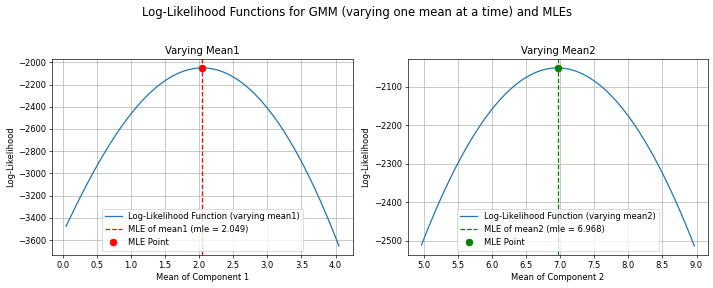

The critical points (MLEs) for Gaussian Mixture Model means are:
  Mean 1 (MLE): 2.049
  Mean 2 (MLE): 6.968


In [45]:
import matplotlib.pyplot as plt

# Fix other parameters at their MLE values
fixed_std1 = stds_mle[0]
fixed_weight1 = weights_mle[0]
fixed_mean2 = means_mle[1]
fixed_std2 = stds_mle[1]
fixed_weight2 = weights_mle[1]

# Choose mean1 as the parameter to vary
mean1_mle = means_mle[0] # Assuming means_mle are sorted such that the first element corresponds to component 1

# Create an array of mean1 values to plot
# We'll range around the MLE for mean1, ensure the MLE is within the plot range
mean1_values = np.linspace(mean1_mle - 2, mean1_mle + 2, 500)

# Calculate the log-likelihood for each mean1 value
log_likelihood_mean1_values = [
    log_likelihood_gmm(gmm_samples, m1_val, fixed_std1, fixed_weight1, fixed_mean2, fixed_std2, fixed_weight2)
    for m1_val in mean1_values
]

# Choose mean2 as the parameter to vary
mean2_mle = means_mle[1]
mean2_values = np.linspace(mean2_mle - 2, mean2_mle + 2, 500)

# Define fixed_mean1 here for the second plot's calculation
fixed_mean1 = means_mle[0]

log_likelihood_mean2_values = [
    log_likelihood_gmm(gmm_samples, fixed_mean1, fixed_std1, fixed_weight1, m2_val, fixed_std2, fixed_weight2)
    for m2_val in mean2_values
]

# Create a figure with two subplots for mean1 and mean2
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=60) # 1 row, 2 columns
fig.suptitle('Log-Likelihood Functions for GMM (varying one mean at a time) and MLEs', fontsize=14)

# Plot for mean1
axes[0].plot(mean1_values, log_likelihood_mean1_values, label='Log-Likelihood Function (varying mean1)')
axes[0].axvline(x=mean1_mle, color='r', linestyle='--', label=f'MLE of mean1 (mle = {mean1_mle:.3f})')
# Add a circle marker at the MLE point for mean1
mle_log_likelihood_mean1 = log_likelihood_gmm(gmm_samples, mean1_mle, fixed_std1, fixed_weight1, fixed_mean2, fixed_std2, fixed_weight2)
axes[0].plot(mean1_mle, mle_log_likelihood_mean1, 'o', color='r', markersize=8, label='MLE Point')
axes[0].set_xlabel('Mean of Component 1') ; axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title('Varying Mean1') ; axes[0].legend() ; axes[0].grid(True)

# Plot for mean2
axes[1].plot(mean2_values, log_likelihood_mean2_values, label='Log-Likelihood Function (varying mean2)')
axes[1].axvline(x=mean2_mle, color='g', linestyle='--', label=f'MLE of mean2 (mle = {mean2_mle:.3f})')
# Add a circle marker at the MLE point for mean2
mle_log_likelihood_mean2 = log_likelihood_gmm(gmm_samples, fixed_mean1, fixed_std1, fixed_weight1, mean2_mle, fixed_std2, fixed_weight2)
axes[1].plot(mean2_mle, mle_log_likelihood_mean2, 'o', color='g', markersize=8, label='MLE Point')
axes[1].set_xlabel('Mean of Component 2') ; axes[1].set_ylabel('Log-Likelihood')
axes[1].set_title('Varying Mean2') ; axes[1].legend() ; axes[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
plt.show()

print(f"The critical points (MLEs) for Gaussian Mixture Model means are:")
print(f"  Mean 1 (MLE): {means_mle[0]:.3f}")
print(f"  Mean 2 (MLE): {means_mle[1]:.3f}")

#### **Gaussian Mixture Statistical Model**

For the Gaussian Mixture Model (GMM), we simulated data from a two-component mixture. Due to the complexity of the GMM's log-likelihood function, a closed-form solution for its Maximum Likelihood Estimates (MLEs) is not feasible. Instead, the Expectation-Maximization (EM) algorithm was employed (via sklearn.mixture.GaussianMixture) to iteratively estimate the parameters (means, standard deviations, and mixing weights) for each component. The visualization involved plotting the log-likelihood function by varying a single parameter (e.g., one of the means) while holding others fixed at their EM-estimated MLEs. These clearly showed a peak at the estimated MLEs, confirming the effectiveness of the EM algorithm in finding the parameter values that maximize the likelihood of the observed GMM data.

### APPENDIX

#### **Critical Point for Bernoulli Model**

The critical point for the Bernoulli distribution's log-likelihood function is found by setting its derivative with respect to p to zero.
The log-likelihood function is given by
- $l(p) = \sum_{i=1}^{n} (x_i \ln(p) + (1-x_i) \ln(1-p))$

Taking the derivative with respect to p
- $\frac{dl(p)}{dp} = \sum_{i=1}^{n} \left( \frac{x_i}{p} - \frac{1-x_i}{1-p} \right)$

Setting the derivative to zero
- $\sum_{i=1}^{n} \frac{x_i}{p} = \sum_{i=1}^{n} \frac{1-x_i}{1-p}$
$\frac{\sum x_i}{p} = \frac{n - \sum x_i}{1-p}$
$(\sum x_i)(1-p) = p(n - \sum x_i)$
$\sum x_i - p \sum x_i = pn - p \sum x_i$
$\sum x_i = pn$
$p_{MLE} = \frac{\sum x_i}{n}$

This shows that the Maximum Likelihood Estimate for $p$ is the sample mean.

**MLE for p.**

The critical point for the Bernoulli distribution's log-likelihood function is found by setting its derivative with respect to $p$ to zero.
The log-likelihood function is given by
- $l(p) = \sum_{i=1}^{n} (x_i \ln(p) + (1-x_i) \ln(1-p))$

Taking the derivative with respect to $p$
- $\frac{dl(p)}{dp} = \sum_{i=1}^{n} \left( \frac{x_i}{p} - \frac{1-x_i}{1-p} \right)$

Setting the derivative to zero
- $\sum_{i=1}^{n} \frac{x_i}{p} = \sum_{i=1}^{n} \frac{1-x_i}{1-p}$
$\frac{\sum x_i}{p} = \frac{n - \sum x_i}{1-p}$
$(\sum x_i)(1-p) = p(n - \sum x_i)$
$\sum x_i - p \sum x_i = pn - p \sum x_i$
$\sum x_i = pn$
$p_{MLE} = \frac{\sum x_i}{n}$

This derivation shows that the Maximum Likelihood Estimate for $p$ is the sample mean, which is the critical point that maximizes the log-likelihood function.


#### **Critical Point for Poisson Model**

The critical point for the Poisson distribution's log-likelihood function is found by setting its derivative with respect to $\lambda$ to zero.
The log-likelihood function for the Poisson distribution (ignoring constant terms that don't depend on $\lambda$) is given by
- $l(\lambda) = \sum_{i=1}^{n} (x_i \ln(\lambda) - \lambda)$

Taking the derivative with respect to $\lambda$
- $\frac{dl(\lambda)}{d\lambda} = \sum_{i=1}^{n} \left( \frac{x_i}{\lambda} - 1 \right)$

Setting the derivative to zero
- $\sum_{i=1}^{n} \frac{x_i}{\lambda} - \sum_{i=1}^{n} 1 = 0$
$\frac{\sum x_i}{\lambda} - n = 0$
$\frac{\sum x_i}{\lambda} = n$
$\lambda_{MLE} = \frac{\sum x_i}{n}$


This derivation shows that the Maximum Likelihood Estimate for $\lambda$ is the sample mean, which is the critical point that maximizes the log-likelihood function.


#### **Critical Point for Uniform Model**

For the Uniform distribution $U(0, \theta)$, the likelihood function is defined as
- $L(\theta | x_1, ..., x_n) = \begin{cases} (1/\theta)^n & \text{if } 0 \le x_i \le \theta \text{ for all } i \\ 0 & \text{otherwise} \end{cases}$

This can be rewritten using indicator functions
- $L(\theta | x_1, ..., x_n) = (1/\theta)^n \cdot I(\theta \ge \max(x_i))$
where $I(\cdot)$ is the indicator function.

The log-likelihood function
- $l(\theta) = \ln( (1/\theta)^n ) + \ln( I(\theta \ge \max(x_i)) )$
- $l(\theta) = -n \ln(\theta) + \ln( I(\theta \ge \max(x_i)) )$

For $L(\theta)$ to be non-zero, $\theta$ must be greater than or equal to the maximum observed value, i.e., $\theta \ge \max(x_i)$.


To maximize $l(\theta)$, we need to minimize $\ln(\theta)$, which means minimizing $\theta$.
Therefore, the function $L(\theta)$ is maximized when $\theta$ is as small as possible, subject to the constraint $\theta \ge \max(x_i)$.
This leads to the Maximum Likelihood Estimate (MLE) for $\theta$ being $\theta_{MLE} = \max(x_i)$.


In this case, the derivative of $l(\theta)$ does not yield a traditional critical point where the derivative is zero, because the maximum occurs at a boundary of the parameter space. The MLE is the boundary point that maximizes the function.


#### **Critical Points for Gaussian Mixture Model**

For Gaussian Mixture Models (GMMs), finding the critical points (Maximum Likelihood Estimates or MLEs) is more complex than for simpler distributions. There is typically no simple closed-form solution for the derivatives of the log-likelihood function that can be set to zero to directly solve for all parameters (means, variances, and mixing coefficients) simultaneously.

Instead, MLEs for GMMs are usually found iteratively using algorithms like the Expectation-Maximization (EM) algorithm. The EM algorithm is an iterative optimization method that finds local maximum likelihood estimates for parameters in statistical models with unobserved latent variables. Each iteration of the EM algorithm increases the log-likelihood of the observed data until it converges to a local maximum.

Therefore, the estimated means, standard deviations, and mixing weights obtained from the EM algorithm are considered the critical points that maximize the log-likelihood function for the GMM. In our previous step, we used sklearn.mixture.GaussianMixture which implements the EM algorithm to find these estimates.

Below, we will print the estimated means (MLEs) for both components, which represent the critical points for the mean parameters.
